### 1. Definir e Processar as features: Métricas que dão informação sobre quem está ganhando


Necessário "pip install chess" pra rodar


In [8]:
!pip install chess

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 54.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for chess: filename=chess-1.11.2-py3-none-any.whl size=147879 sha256=69e21ef0bf6185c16c9100be0fbb3ef5b02a89e472f22ecc2fe20e3c5e7350c9
  Stored in directory: /root/.cache/pip/wheels/74/65/99/8c3a88ba852c1ed8d34daed144b8cb4c654d638677483d19ff
Successfully built chess


In [9]:
import chess
import chess.svg
from IPython.display import SVG, display

PIECE_VALUES = {
    chess.PAWN: 1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK: 5,
    chess.QUEEN: 9,
    chess.KING: 0
}


def get_check_status(board, player):
    return 1 if board.is_check() else 0


def get_has_castled(board, color):
    replay = chess.Board()
    for move in board.move_stack:
        if replay.is_castling(move) and replay.turn == color:
            return True
        replay.push(move)
    return False


def get_en_passant(board):
    ep = board.ep_square
    if ep is None:
        return {'En Passant (possible)': 0, 'En Passant (column)': 0}

    col = chess.square_file(ep) + 1
    return {'En Passant (possible)': 1, 'En Passant (column)': col}


def get_material(board, player, opponent):
    player_mat = sum(len(board.pieces(pt, player)) * val for pt, val in PIECE_VALUES.items())
    opp_mat = sum(len(board.pieces(pt, opponent)) * val for pt, val in PIECE_VALUES.items())
    return {
        'Player Material': player_mat,
        'Opponent Material': opp_mat,
        'Net Material': player_mat - opp_mat
    }


def get_pawn_structure(board, player, opponent):
    features = {
        'Player Isolated Pawns': 0, 'Opponent Isolated Pawns': 0,
        'Player Doubled Pawns': 0, 'Opponent Doubled Pawns': 0,
        'Player Passed Pawns': 0, 'Opponent Passed Pawns': 0
    }

    for color, prefix in [(player, 'Player'), (opponent, 'Opponent')]:
        pawns = board.pieces(chess.PAWN, color)
        enemy_pawns = board.pieces(chess.PAWN, not color)

        pawn_files = [0] * 8
        for sq in pawns:
            pawn_files[chess.square_file(sq)] += 1

        for sq in pawns:
            file = chess.square_file(sq)
            rank = chess.square_rank(sq)

            if pawn_files[file] > 1:
                features[f'{prefix} Doubled Pawns'] += 1

            left_isolated = (file == 0) or (pawn_files[file - 1] == 0)
            right_isolated = (file == 7) or (pawn_files[file + 1] == 0)
            if left_isolated and right_isolated:
                features[f'{prefix} Isolated Pawns'] += 1

            is_white = color == chess.WHITE
            passed = True
            for enemy_sq in enemy_pawns:
                e_file = chess.square_file(enemy_sq)
                e_rank = chess.square_rank(enemy_sq)

                if abs(e_file - file) <= 1:
                    if (is_white and e_rank > rank) or (not is_white and e_rank < rank):
                        passed = False
                        break
            if passed:
                features[f'{prefix} Passed Pawns'] += 1

    return features


def get_king_safety(board, player, opponent):
    features = {}
    for color, prefix in [(player, 'Player'), (opponent, 'Opponent')]:
        king_sq = board.king(color)
        if king_sq is None:
            continue

        features[f'{prefix} King Column'] = chess.square_file(king_sq) + 1
        features[f'{prefix} King Line'] = chess.square_rank(king_sq) + 1

        adjacent_squares = [
            sq for sq in chess.SQUARES
            if chess.square_distance(king_sq, sq) == 1
        ]

        attacks = 0
        enemies = 0
        allies = 0
        free = 0

        for sq in adjacent_squares:
            if board.is_attacked_by(not color, sq):
                attacks += 1

            piece = board.piece_at(sq)
            if piece is None:
                free += 1
            elif piece.color == color:
                allies += 1
            else:
                enemies += 1

        features[f'{prefix} King Adjacent Attacks'] = attacks
        features[f'{prefix} King Adjacent Enemies'] = enemies
        features[f'{prefix} King Adjacent Allies'] = allies
        features[f'{prefix} King Adjacent Free'] = free

    return features


def get_center_control(board, player, opponent):
    # As 4 casas do centro
    center_squares = [chess.D4, chess.E4, chess.D5, chess.E5]

    features = {
        'Player Center Occupation': 0, 'Opponent Center Occupation': 0,
        'Player Center Attacks': 0,    'Opponent Center Attacks': 0
    }

    for sq in center_squares:
        #Verifica quem está fisicamente no centro
        piece = board.piece_at(sq)
        if piece is not None:
            if piece.color == player:
                features['Player Center Occupation'] += 1
            else:
                features['Opponent Center Occupation'] += 1
        #Conta quantas peças de cada cor estão atacando/defendendo essa casa
        features['Player Center Attacks'] += len(board.attackers(player, sq))
        features['Opponent Center Attacks'] += len(board.attackers(opponent, sq))

    return features

def get_mobility_by_piece(board, player, opponent):
    piece_names = {
        chess.KNIGHT: 'Knight', chess.BISHOP: 'Bishop',
        chess.ROOK: 'Rook', chess.QUEEN: 'Queen'
    }
    features = {}
    for color, prefix in [(player, 'Player'), (opponent, 'Opponent')]:
        for pt, name in piece_names.items():
            count = 0
            for sq in board.pieces(pt, color):
                count += len(board.attacks(sq))
            features[f'{prefix} {name} Mobility'] = count
    return features


def extract_all_features(board):
    player = board.turn
    opponent = not player

    features = {}
    features['Check'] = get_check_status(board, player)
    features['Player Has Castled'] = get_has_castled(board, player)
    features['Opponent Has Castled'] = get_has_castled(board, opponent)
    features.update(get_en_passant(board))
    features.update(get_material(board, player, opponent))
    features.update(get_mobility_by_piece(board, player, opponent))
    features.update(get_pawn_structure(board, player, opponent))
    features.update(get_king_safety(board, player, opponent))
    features.update(get_center_control(board, player, opponent))
    return features

### Heurística: Score dos dois players

In [10]:
def estimate_score(board, func):
    if board.is_checkmate():
        return -1000
    feat = extract_all_features(board)
    return func(feat)

def initial_score(feat):
    score =  -0.1*feat['Check']
    score += 0.1*feat['Player Has Castled']
    score += -0.1*feat['Opponent Has Castled']
    score += feat['Player Material']
    score -= feat['Opponent Material']
    score += -0.1*feat['Player Isolated Pawns']
    score += 0.1*feat['Opponent Isolated Pawns']
    score += -0.1*feat['Player Doubled Pawns']
    score += 0.1*feat['Opponent Doubled Pawns']
    score += 0.2*feat['Player Passed Pawns']
    score += -0.2*feat['Opponent Passed Pawns']
    score += 0.08*feat['Player Knight Mobility'] - 0.08*feat['Opponent Knight Mobility']
    score += 0.08*feat['Player Bishop Mobility'] - 0.08*feat['Opponent Bishop Mobility']
    score += 0.05*feat['Player Rook Mobility']   - 0.05*feat['Opponent Rook Mobility']
    score += 0.015*feat['Player Queen Mobility'] - 0.015*feat['Opponent Queen Mobility']
    score += -0.2*feat['Player King Adjacent Attacks']
    score += 0.2*feat['Opponent King Adjacent Attacks']
    score += 0.25 * feat['Player Center Occupation']
    score += -0.25 * feat['Opponent Center Occupation']
    score += 0.05 * feat['Player Center Attacks']
    score += -0.05 * feat['Opponent Center Attacks']

    return score

### Algoritmo de busca pra escolher o próximo movimento, considerando a heurística


In [11]:
import gc
import random
import math
import pandas as pd


class TrainingTree:

    class Node:
        def __init__(self, score):
            self.original_score = score
            self.current_score = score
            self.prob = 1
            self.children = {}
            self.parent = None
            self.player = True
            self.tree = None

        def create_children(self, move, func):
            self.tree.board.push(move)
            score = estimate_score(self.tree.board, func)
            node = TrainingTree.Node(score)
            node.parent = self
            node.player = not self.player
            node.tree = self.tree
            self.children[move.uci()] = node
            self.tree.board.pop()

        def update_scores(self):
            if len(self.children) > 0:
                scores = []
                for child in self.children.values():
                    scores.append(-child.current_score)
                max_score = max(scores)
                self.current_score = max_score
                sum_exp = 0
                exp_scores = []
                for s in scores:
                    e = math.exp((s-max_score)/self.tree.T)
                    exp_scores.append(e)
                    sum_exp += e
                i = 0
                for child in self.children.values():
                    child.prob = exp_scores[i]/sum_exp
                    i += 1

            if self.parent != None and self.current_score != self.original_score:
                self.parent.update_scores()


    def __init__(self, board, score, T):
        self.board = board
        self.T = T
        self.root = self.Node(score)
        self.root.tree = self
        self.root.player = (self.board.turn == chess.WHITE)

    def explore_one_step(self, func, tolerance=50):
        i = 0
        # Se em K tentativas só encontra checkmate, desiste de procurar
        node = self.root
        while i < tolerance:
            node = self.root
            while len(node.children) > 0:
                moves = list(node.children.keys())
                children_nodes = list(node.children.values())
                probs = [c.prob for c in children_nodes]

                move = random.choices(moves, weights=probs)[0]
                self.board.push(chess.Move.from_uci(move))
                node = node.children[move]

            if self.board.is_checkmate():
                while node.parent != None:
                    node = node.parent
                    self.board.pop()
                i += 1
            else:
                break

        # Só prossegue se encontrou alguma coisa que não seja checkmate
        if i >= tolerance:
            return False
        legal_moves = list(self.board.legal_moves)
        for legal_move in legal_moves:
            node.create_children(legal_move, func)
        # Movimento de retorno
        node.update_scores()
        while node.parent != None:
            node = node.parent
            self.board.pop()
        return True

    def explore(self, func, N, tolerance=50):
        for i in range(N):
            found_move = self.explore_one_step(func, tolerance)
            if not found_move:
                break

    def tree_make_moves(self, moves, func):
        current_root = self.root
        for move in moves:
            try:
                self.root = self.root.children[move.uci()]
            except:
                self.root.create_children(move, func)
                self.root = self.root.children[move.uci()]
            self.board.push(move)
        self.root.parent = None
        del current_root
        gc.collect()

    def get_target_score(self):
        return self.root.current_score

    def get_original_score(self):
        return self.root.original_score

    def get_best_features(self):
        node = self.root
        target_score = self.get_target_score()
        while len(node.children) > 0:
            for move, child in node.children.items():
                if child.current_score == target_score:
                    node = child
                    self.board.push(chess.Move.from_uci(move))
                    break
            return None
        feat = extract_all_features(self.board)
        while node.parent != None:
            node = node.parent
            self.tree.board.pop()
        return feat

    def get_best_move(self):
        max_score = 0
        best_move = None
        for move, child in self.root.children.items():
            if best_move == None or -child.current_score > max_score:
                best_move = move
                max_score = -child.current_score
        return chess.Move.from_uci(best_move)

def create_tree(board, func, T):
    score = estimate_score(board, func)
    training_tree = TrainingTree(board, score, T)
    return training_tree


if __name__ == "__main__":
    board = chess.Board()

    A = ['e2e4',
         'e7e6',
         'd2d4',
         ]

    for move in A:
        board.push(chess.Move.from_uci(move))

    func = initial_score
    T = 1
    N = 500
    tolerance = 50
    training_tree = create_tree(board, func, T)
    training_tree.explore(func, N, tolerance)
    print(training_tree.get_best_move())
    print(f"Score original: {training_tree.root.original_score}")
    print(f"Score melhorado: {training_tree.root.current_score}")
    print("Divisão por jogada:")
    for move, child in training_tree.root.children.items():
        print(f"{move}: {child.current_score}")




d7d5
Score original: -0.95
Score melhorado: -0.81
Divisão por jogada:
g8e7: 1.525
g8h6: 4.155
g8f6: 0.9799999999999999
f8e7: 1.21
f8d6: 1.045
f8c5: 4.2250000000000005
f8b4: 0.8199999999999998
f8a3: 4.56
e8e7: 1.85
d8e7: 1.5799999999999998
d8f6: 1.16
d8g5: 10.725
d8h4: 1.0599999999999998
b8c6: 1.0699999999999998
b8a6: 4.140000000000001
h7h6: 1.9149999999999996
g7g6: 1.255
f7f6: 1.105
d7d6: 1.5949999999999998
c7c6: 1.5399999999999996
b7b6: 1.23
a7a6: 1.5699999999999998
e6e5: 2.045
h7h5: 1.4
g7g5: 1.3550000000000002
f7f5: 1.2600000000000002
d7d5: 0.81
c7c5: 1.875
b7b5: 1.5
a7a5: 1.2349999999999999


### Loop: Rodando um Jogo Real Interativo

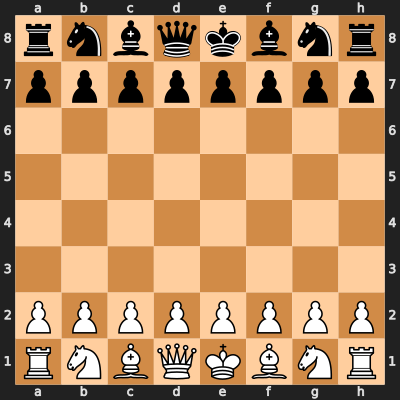

Você quer jogar de Brancas ou Pretas? (b/p): b
Sua jogada: e2e4


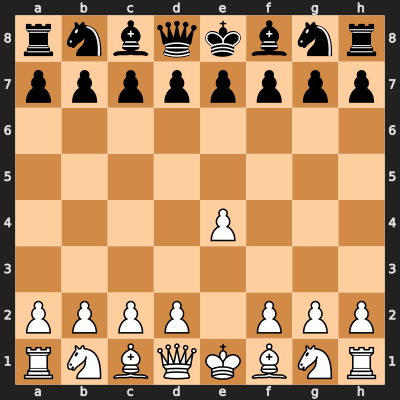

Computador: g8f6


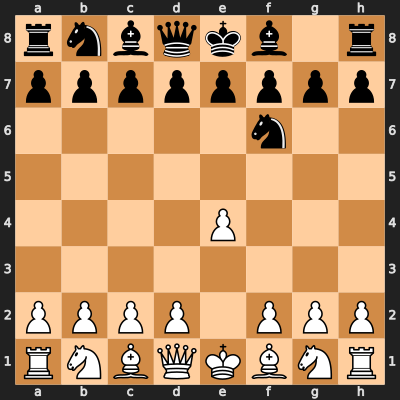

Sua jogada: b1c3


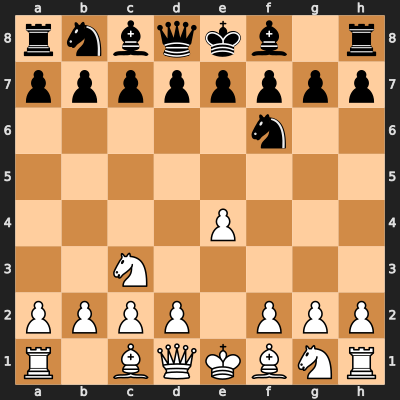

Computador: b8c6


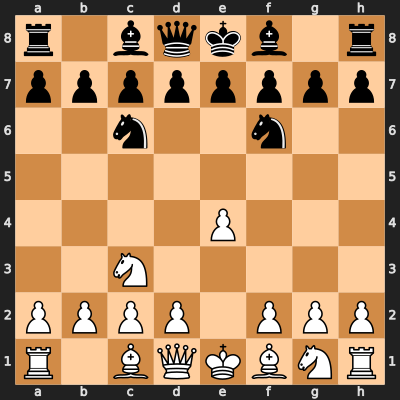

Sua jogada: d2d4


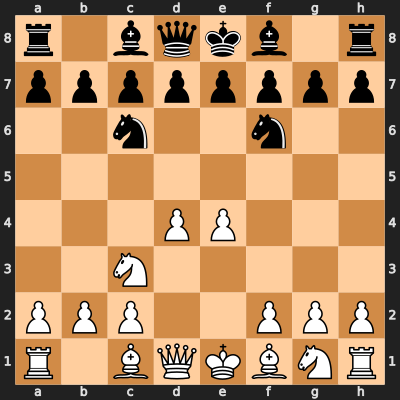

Computador: e7e5


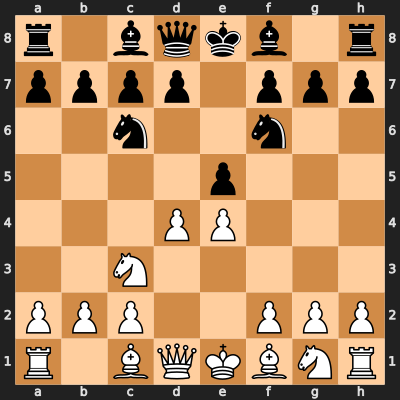

Sua jogada: g1f3


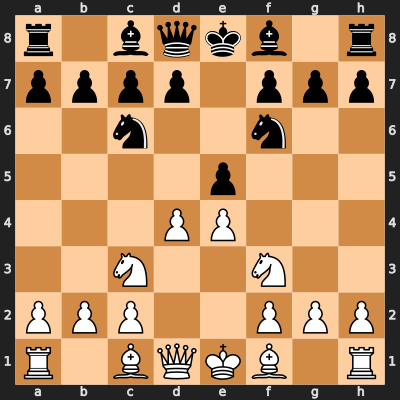

Computador: d7d5


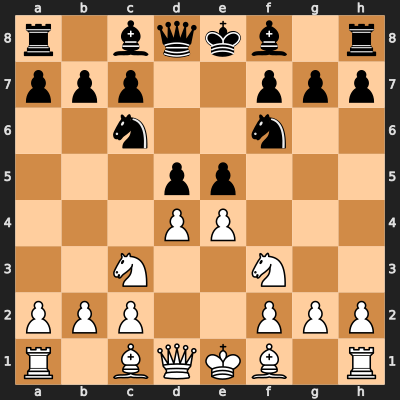

Sua jogada: f1d3


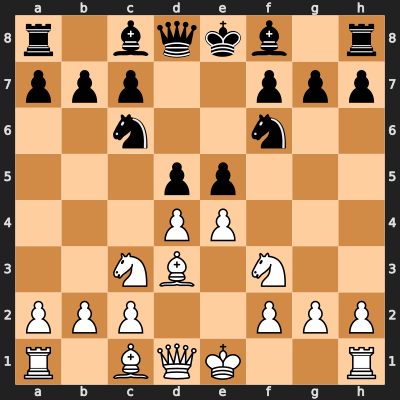

Computador: f6e4


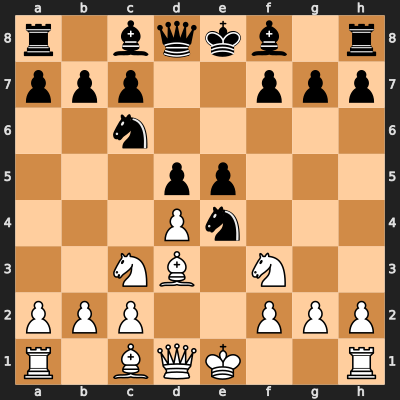

Sua jogada: d2e4
Jogada inválida. Digite uma jogada válida em notação UCI, 'stop' para parar o jogo ou 'explain' para ver a explicação do movimento.
Sua jogada: d3e4


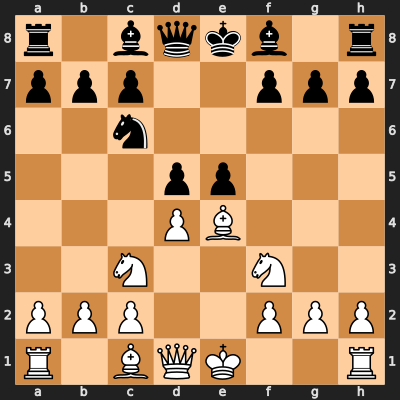

Computador: d5e4


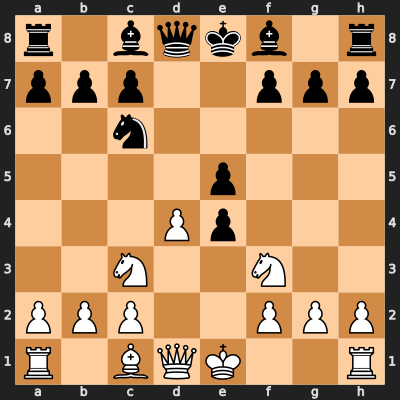

Sua jogada: c3e4


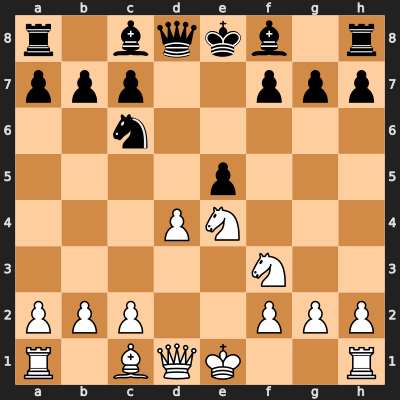

Computador: e5d4


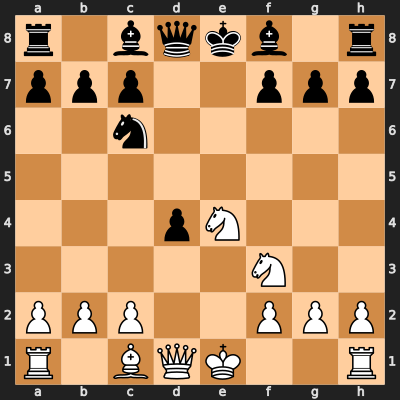

Sua jogada: e1g1


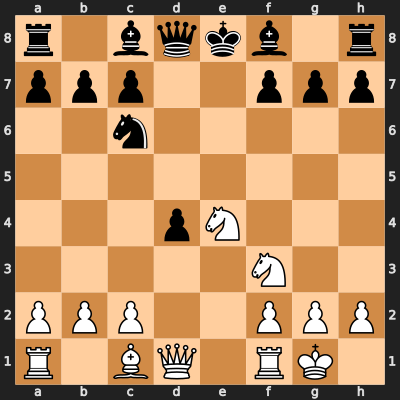

Computador: d8d5


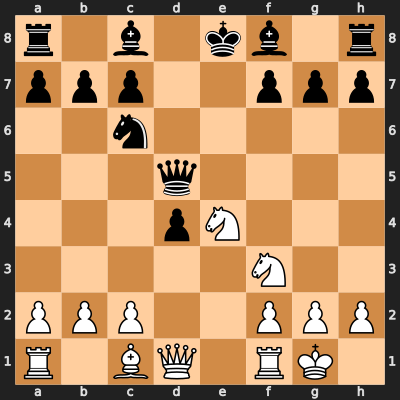

Sua jogada: f1e1


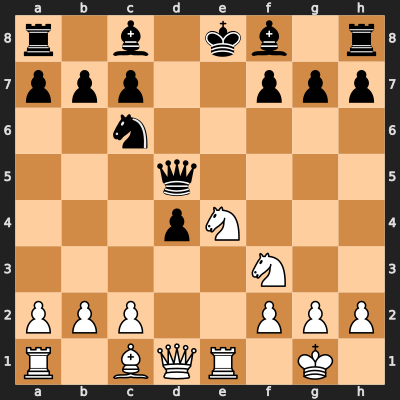

Computador: c8e6


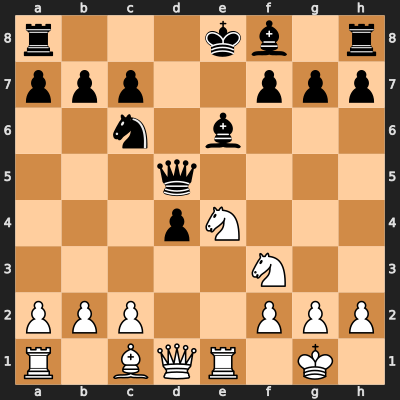

In [ ]:
#Classe ChessBoard fornecida pelo professor
class ChessBoard:

    """Wraps python-chess and renders itself as SVG in Jupyter."""

    def __init__(self, fen: str = None, size: int = 400):
        self.board = chess.Board(fen) if fen else chess.Board()
        self.size = size

    def push(self, move: str):
        """Play a move in SAN ('e4', 'Nf3') or UCI ('e2e4') notation."""
        try:
            self.board.push_san(move)
        except ValueError:
            self.board.push_uci(move)
        return self

    def pop(self):
        self.board.pop()
        return self

    def reset(self):
        self.board.reset()
        return self

    def legal_moves(self) -> list[str]:
        return [self.board.san(m) for m in self.board.legal_moves]

    def is_game_over(self) -> bool:
        return self.board.is_game_over()

    def result(self) -> str:
        return self.board.result()

    def _svg(self) -> str:
        last_move = self.board.peek() if self.board.move_stack else None
        check_square = self.board.king(self.board.turn) if self.board.is_check() else None
        return chess.svg.board(
            self.board,
            size=self.size,
            lastmove=last_move,
            check=check_square,
        )

    def show(self):
        display(SVG(self._svg()))

    def _repr_svg_(self):
        # lets Jupyter auto-render the board when it's the last line in a cell
        return self._svg()

board = chess.Board()
ChessBoard(fen=board.fen()).show()
func = initial_score
T = 1
N = 500

color_choice = input("Você quer jogar de Brancas ou Pretas? (b/p): ")
player = (color_choice.lower() == 'b')
end = False

callback = [None, None]
training_tree = None

while not end:
    if player:
        move_done = False
        while not move_done:
            move = input("Sua jogada: ")
            if move == 'stop':
                end = True
                break
            elif move == 'explain' and training_tree != None:
                print(f"Score original: {training_tree.root.original_score}")
                print(f"Score melhorado: {training_tree.root.current_score}")
                print("Divisão por jogada:")
                for m, child in training_tree.root.children.items():
                    print(f"{m}: {child.current_score}")
            else:
                moves = []
                for m in list(board.legal_moves):
                    moves.append(m.uci())
                if move in moves:
                    board.push(chess.Move.from_uci(move))
                    callback[1] = chess.Move.from_uci(move)
                    move_done = True
                    ChessBoard(fen=board.fen()).show()
                else:
                    print("Jogada inválida. Digite uma jogada válida em notação UCI, 'stop' para parar o jogo ou 'explain' para ver a explicação do movimento.")
        player = False
        if board.is_checkmate():
            print("Você venceu!")
            end = True
        elif board.is_game_over():
            print("Empate!")
            end = True
    else:
        if training_tree == None:
            training_tree = create_tree(board, func, T)
        else:
            board.pop()
            board.pop()
            training_tree.tree_make_moves(callback, func)
        training_tree.explore(func, N)
        move = training_tree.get_best_move()
        print(f"Computador: {move.uci()}")
        board.push(move)
        ChessBoard(fen=board.fen()).show()
        callback[0] = move
        player = True
        if board.is_checkmate():
            print("Você perdeu!")
            end = True
        elif board.is_game_over():
            print("Empate!")
            end = True